In [35]:
import random
from pathlib import Path
from typing import Iterable
import time

import matplotlib.pyplot as plt
import networkit as nk
import networkx as nx
import numpy as np
from networkit.embedding import Node2Vec
from sklearn.metrics import f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
nk.engineering.setNumberOfThreads(1)

## Networkit documentation
https://networkit.github.io/dev-docs/python_api/modules.html

## Loading network

In [7]:
data_path = Path('citeseer.adjlist')
G_nx = nx.read_adjlist(data_path, nodetype=int)
G_nk = nk.nxadapter.nx2nk(G_nx)
print(f'Graph loaded: {G_nk.numberOfNodes()} nodes, {G_nk.numberOfEdges()} edges')

Graph loaded: 3327 nodes, 4552 edges


#### Mapping

węzły w grafie networkit są inaczej indeksowane niz w oryginalnym pliku (grafie NX), więc potrzebna jest funkcja do mapowania 

In [33]:
nx_nodes = list(G_nx.nodes())

# NK -> NX
nk_to_nx = {i: node for i, node in enumerate(nx_nodes)}

# NX -> NK
nx_to_nk = {node: i for i, node in enumerate(nx_nodes)}

### 1b) Porównanie czasu wykonania poszczególnych algorytmów dla obu bibliotek

- Betweenness centrality

In [36]:
time_0 = time.time()
bc_nx = nx.betweenness_centrality(G_nx)
time_bc_nx = time.time() - time_0

time_0 = time.time()
bc_nk = nk.centrality.Betweenness(G_nk, normalized=True)
bc_nk.run()
time_bc_nk = time.time() - time_0

time_0 = time.time()
bc_nk_est = nk.centrality.EstimateBetweenness(G_nk, nSamples=100, normalized=True)
bc_nk_est.run()
time_bc_nk_est = time.time() - time_0

print(f'Betweenness centrality computed in {time_bc_nx:.2f} seconds (NetworkX)')
print(f'Betweenness centrality computed in {time_bc_nk:.2f} seconds (NetworKit)')
print(f'Betweenness centrality estimated in {time_bc_nk_est:.2f} seconds (NetworKit Estimate)')

Betweenness centrality computed in 9.06 seconds (NetworkX)
Betweenness centrality computed in 1.10 seconds (NetworKit)
Betweenness centrality estimated in 0.04 seconds (NetworKit Estimate)


- Liczba połączonych komponentów

In [40]:
time_0 = time.time()
n_components_nx = nx.number_connected_components(G_nx)
time_nx_components = time.time() - time_0

time_0 = time.time()
n_components_nk = nk.components.ConnectedComponents(G_nk)
n_components_nk.run()
time_nk_components = time.time() - time_0

print(f'Number of connected components computed in {time_nx_components:.5f} seconds (NetworkX)')
print(f'Number of connected components computed in {time_nk_components:.5f} seconds (NetworKit)')

Number of connected components computed in 0.00108 seconds (NetworkX)
Number of connected components computed in 0.00027 seconds (NetworKit)


Biblioteka NetworKit jest znacznie szybsza od biblioteki NetworkiX, szczególnie dla duzych grafów, dzięki implementacji w C++. NetworkiX natomiast jest trochę bardziej przyjazny w uzyciu i ma bogatsze API

### 1c) Analiza sieci z overwiew i networkit.centrality

In [57]:
# ogólny przegląd sieci
nk.overview(G_nk)

# degree centrality
dc = nk.centrality.DegreeCentrality(G_nk)
dc.run()
dc_scores = dc.scores()

betweenness = nk.centrality.Betweenness(G_nk)
betweenness.run()
betweenness_scores = betweenness.scores()

# PageRank
pr = nk.centrality.PageRank(G_nk)
pr.run()
pr_scores = pr.scores()

# mapowanie wyników z NK do NX
dc_dict = {nk_to_nx[i]: score for i, score in enumerate(dc_scores)}
betweenness_dict = {nk_to_nx[i]: score for i, score in enumerate(betweenness_scores)}
pr_dict = {nk_to_nx[i]: score for i, score in enumerate(pr_scores)}

top_degree = sorted(dc_dict.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 degree centrality:", top_degree)

top_betweenness = sorted(betweenness_dict.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 betweenness:", top_betweenness)

top_pagerank = sorted(pr_dict.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 PageRank:", top_pagerank)

Network Properties:
nodes, edges			3327, 4552
directed?			False
weighted?			False
isolated nodes			48
self-loops			0
density				0.000823
clustering coefficient		0.141471
min/max/avg degree		0, 99, 2.736399
degree assortativity		0.142213
number of connected components	438
size of largest component	2120 (63.72 %)

Top 5 degree centrality: [(1422, 99.0), (582, 51.0), (1214, 35.0), (2782, 34.0), (1943, 30.0)]

Top 5 betweenness: [(1620, 810432.5261862912), (1422, 658637.2283625852), (582, 607301.3847152102), (450, 581719.966716982), (1817, 510099.4176756419)]

Top 5 PageRank: [(1422, 0.005302822752110538), (582, 0.004327506507221055), (3193, 0.001807849493435678), (1620, 0.0016959099916917795), (541, 0.0016265013007417078)]


Analizowana sieć jest nieskierowanym, niewazonym i rzadkim grafem co wynika z bardzo niskiego współczynnika gęstości (bliki zera) oraz małą liczbą krawędzie w porównaniu do liczby węzłów. Graf składa się z wielu połączonych komponentów, z czego największy obejmuje około 64% wierzchołków. 

### 1d) Wykres rozkładu stopni

In [54]:
from collections import Counter


def plot_degree_distribution(G: nk.Graph, title: str):
    degrees = [G.degree(i) for i in G.iterNodes()]
    
    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(degrees, bins=50, color='blue', edgecolor='black')
    axes[0].set_title('Rozkład stopni węzłów')
    axes[0].set_xlabel('Stopień węzła')
    axes[0].set_ylabel('Liczba węzłów')
    axes[0].grid(axis='y', alpha=0.75)

    deg_count = Counter(degrees)
    x = sorted(deg_count.keys())
    y = [deg_count[k] for k in x]
    axes[1].loglog(x, y, 'o', markersize=4, color='blue')
    axes[1].set_title('Rozkład stopni węzłów (skala log-log)')
    axes[1].set_xlabel('Stopień węzła')
    axes[1].set_ylabel('Liczba węzłów')
    plt.tight_layout()
    plt.show()

    print(f"Średni stopień: {np.mean(degrees):.2f}, Max: {max(degrees)}")


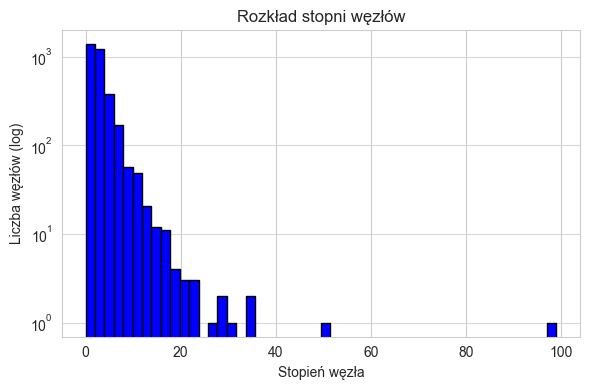

Średni stopień: 2.74, Max: 99


In [60]:
nk_degrees = [G_nk.degree(i) for i in G_nk.iterNodes()]

plt.figure(figsize=(6, 4))
plt.hist(nk_degrees, bins=50, color='blue', edgecolor='black')
plt.yscale('log')
plt.title('Rozkład stopni węzłów')
plt.xlabel('Stopień węzła')
plt.ylabel('Liczba węzłów (log)')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

print(f"Średni stopień: {np.mean(nk_degrees):.2f}, Max: {max(nk_degrees)}")

Analizowana sieć ma średni stopień wynoszący 2.74, natomiast widoczne są tez węzły o bardzo duzej liczbie stopnia węzła, co sugeruje występowanie duzych HUB-ów w grafie. Rozkład stopni przypomina rozkład potęgowy, co moze sugerować, ze moze być to sieć real-world

## Sparsification

sparsyfikacja jest jednym z typów redukcji grafu, która wybiera istotne węzły i krawędzie, odrzucając pozostałe. W trakcie działania procesu dla danego grafu $G = (A, X)$,  model sparsyfikacji grafu wybiera istniejące węzły lub krawędzie z grafu $G$, tworząc $G' = (A', X')$. Innymi słowy, elementy $A'$ lub $X'$ są podzbiorem elementów w $A$ lub $X$.

In [ ]:
edge_ratio = 0.5

### 2a) Sparsyfikacja sieci algorytmem RandomEdgeSparsifier dla edgeRatio = 0.25

In [53]:
edge_ratio = 0.25

# indeksowanie krawędzi (niezbędne do niektórych algorytmów sparsification)
G_nk.indexEdges()

random_sparsifier = nk.sparsification.RandomEdgeSparsifier()
G_sparsified = random_sparsifier.getSparsifiedGraphOfSize(G_nk, edge_ratio)

print(f"Oryginal graph: {G_nk.numberOfNodes()} nodes, {G_nk.numberOfEdges()} edges")
print(f"Sparsified graph: {G_sparsified.numberOfNodes()} nodes, {G_sparsified.numberOfEdges()} edges")
print(f"Edges kept: {G_sparsified.numberOfEdges() / G_nk.numberOfEdges() * 100:.2f}%")

Oryginal graph: 3327 nodes, 4552 edges
Sparsified graph: 3327 nodes, 1131 edges
Edges kept: 24.85%


### 2b) Analiza zredukowanej sieci

Network Properties:
nodes, edges			3327, 1131
directed?			False
weighted?			False
isolated nodes			1842
self-loops			0
density				0.000204
clustering coefficient		0.006201
min/max/avg degree		0, 39, 0.679892
degree assortativity		0.075156
number of connected components	2262
size of largest component	277 (8.33 %)


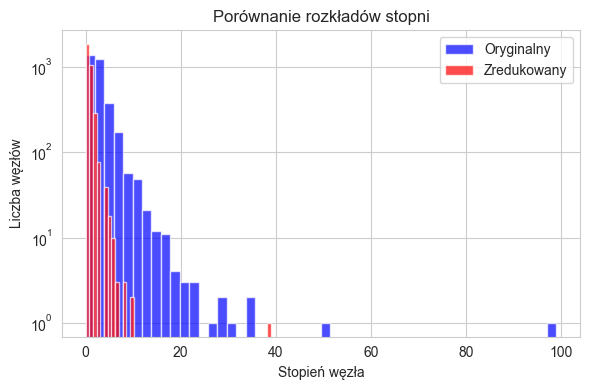

In [79]:
nk.overview(G_sparsified)

degrees_sparsified = [G_sparsified.degree(i) for i in G_sparsified.iterNodes()]

plt.figure(figsize=(6, 4))
plt.hist(nk_degrees, bins=50, color='blue', alpha=0.7, label='Oryginalny', edgecolor='white')
plt.hist(degrees_sparsified, bins=50, color='red', alpha=0.7, label='Zredukowany', edgecolor='white')
plt.yscale('log')
plt.xlabel('Stopień węzła')
plt.ylabel('Liczba węzłów')
plt.title('Porównanie rozkładów stopni')
plt.legend()
plt.tight_layout()
plt.show()

### 2c) Inny algorytm sparsyfikacji - ForestFireSparsifier

In [80]:
local_sparsifier = nk.sparsification.LocalDegreeSparsifier()
G_local_sparsified = local_sparsifier.getSparsifiedGraphOfSize(G_nk, edge_ratio)

print(f"Oryginal graph: {G_nk.numberOfNodes()} nodes, {G_nk.numberOfEdges()} edges")
print(f"Local Degree Sparsified graph: {G_local_sparsified.numberOfNodes()} nodes, {G_local_sparsified.numberOfEdges()} edges")
print(f"Edges kept: {G_local_sparsified.numberOfEdges() / G_nk.numberOfEdges() * 100:.2f}%")

Oryginal graph: 3327 nodes, 4552 edges
Local Degree Sparsified graph: 3327 nodes, 2817 edges
Edges kept: 61.88%


Network Properties:
nodes, edges			3327, 2817
directed?			False
weighted?			False
isolated nodes			48
self-loops			0
density				0.000509
clustering coefficient		0.000000
min/max/avg degree		0, 99, 1.693417
degree assortativity		-0.032334
number of connected components	510
size of largest component	634 (19.06 %)


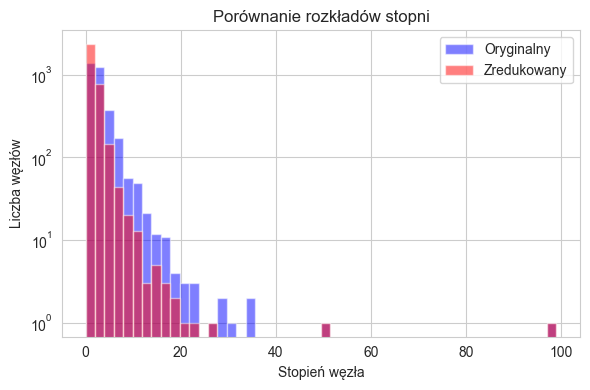

In [82]:
nk.overview(G_local_sparsified)

degrees_sparsified = [G_local_sparsified.degree(i) for i in G_local_sparsified.iterNodes()]

plt.figure(figsize=(6, 4))
plt.hist(nk_degrees, bins=50, color='blue', alpha=0.5, label='Oryginalny', edgecolor='white')
plt.hist(degrees_sparsified, bins=50, color='red', alpha=0.5, label='Zredukowany', edgecolor='white')
plt.yscale('log')
plt.xlabel('Stopień węzła')
plt.ylabel('Liczba węzłów')
plt.title('Porównanie rozkładów stopni')
plt.legend()
plt.tight_layout()
plt.show()


Wykorzsytano dwie rózne metody sparsyfikacji: RandomEdgeSparsifier oraz LocalDegreeSparsifier.

Porównanie:

- RandomEdgeSparsifier: losowo ograniczył graf, tak aby zachować tylko podaną przez nas część krawędzi (25%). Losowe usuwanie krawędzi spowowdowało zaburzenie struktury grafu (widać to dobrze na rozkładzie stopni). Dodatkowo znacznie zwiększyła się liczba komponentów w grafie prowadząc do większej fragmentacji sieci

- LocalDegreeSparsifier: ogranicza graf tak zeby dązyć do podanego procentu krawędzi, ale jednocześnie zachowując strukturę grafu, przez co ostatecznie zachowuje znacznie więcej krawędzi niz było to przez nas określone. Na wykresie dobrze widać zachowanie struktury oraz hubów z początkowego grafu. tutaj równiez doszło do fragmentacji, ale jest ona znacznie mniejsza niz w przypadku drugiej metody

### 2d) Wpływ edgeRatio

In [92]:
ratios = [0.1, 0.25, 0.5, 0.75, 0.9]
results = {'random': [], 'local_degree': []}

for ratio in ratios:
    random_sparsifier = nk.sparsification.RandomEdgeSparsifier()
    G_sparsified = random_sparsifier.getSparsifiedGraphOfSize(G_nk, ratio)
    local_sparsifier = nk.sparsification.LocalDegreeSparsifier()
    G_local_sparsified = local_sparsifier.getSparsifiedGraphOfSize(G_nk, ratio)
    
    nodes = G_sparsified.numberOfNodes()
    edges = G_sparsified.numberOfEdges()
    n_components = nk.components.ConnectedComponents(G_sparsified)
    n_components.run()
    num_components = n_components.numberOfComponents()
    largest_component_size = len(max(n_components.getComponents(), key=len)) if num_components > 0 else 0
    clustering_coefficient = nk.centrality.LocalClusteringCoefficient(G_sparsified)
    clustering_coefficient.run()
    scores = clustering_coefficient.scores()
    avg_clustering_coefficient = sum(scores) / len(scores) if scores else 0
    avg_degree = 2 * edges / nodes if nodes > 0 else 0

    results['random'].append((ratio, nodes, edges, num_components, largest_component_size, avg_clustering_coefficient, avg_degree))

    nodes = G_local_sparsified.numberOfNodes()
    edges = G_local_sparsified.numberOfEdges()
    n_components_local = nk.components.ConnectedComponents(G_local_sparsified)
    n_components_local.run()
    num_components_local = n_components_local.numberOfComponents()
    largest_component_size_local = len(max(n_components_local.getComponents(), key=len)) if num_components_local > 0 else 0
    clustering_coefficient_local = nk.centrality.LocalClusteringCoefficient(G_local_sparsified)
    clustering_coefficient_local.run()
    scores_local = clustering_coefficient_local.scores()
    avg_clustering_coefficient_local = sum(scores_local) / len(scores_local) if scores_local else 0
    avg_degree_local = 2 * edges / nodes if nodes > 0 else 0

    results['local_degree'].append((ratio, nodes, edges, num_components_local, largest_component_size_local, avg_clustering_coefficient_local, avg_degree_local))

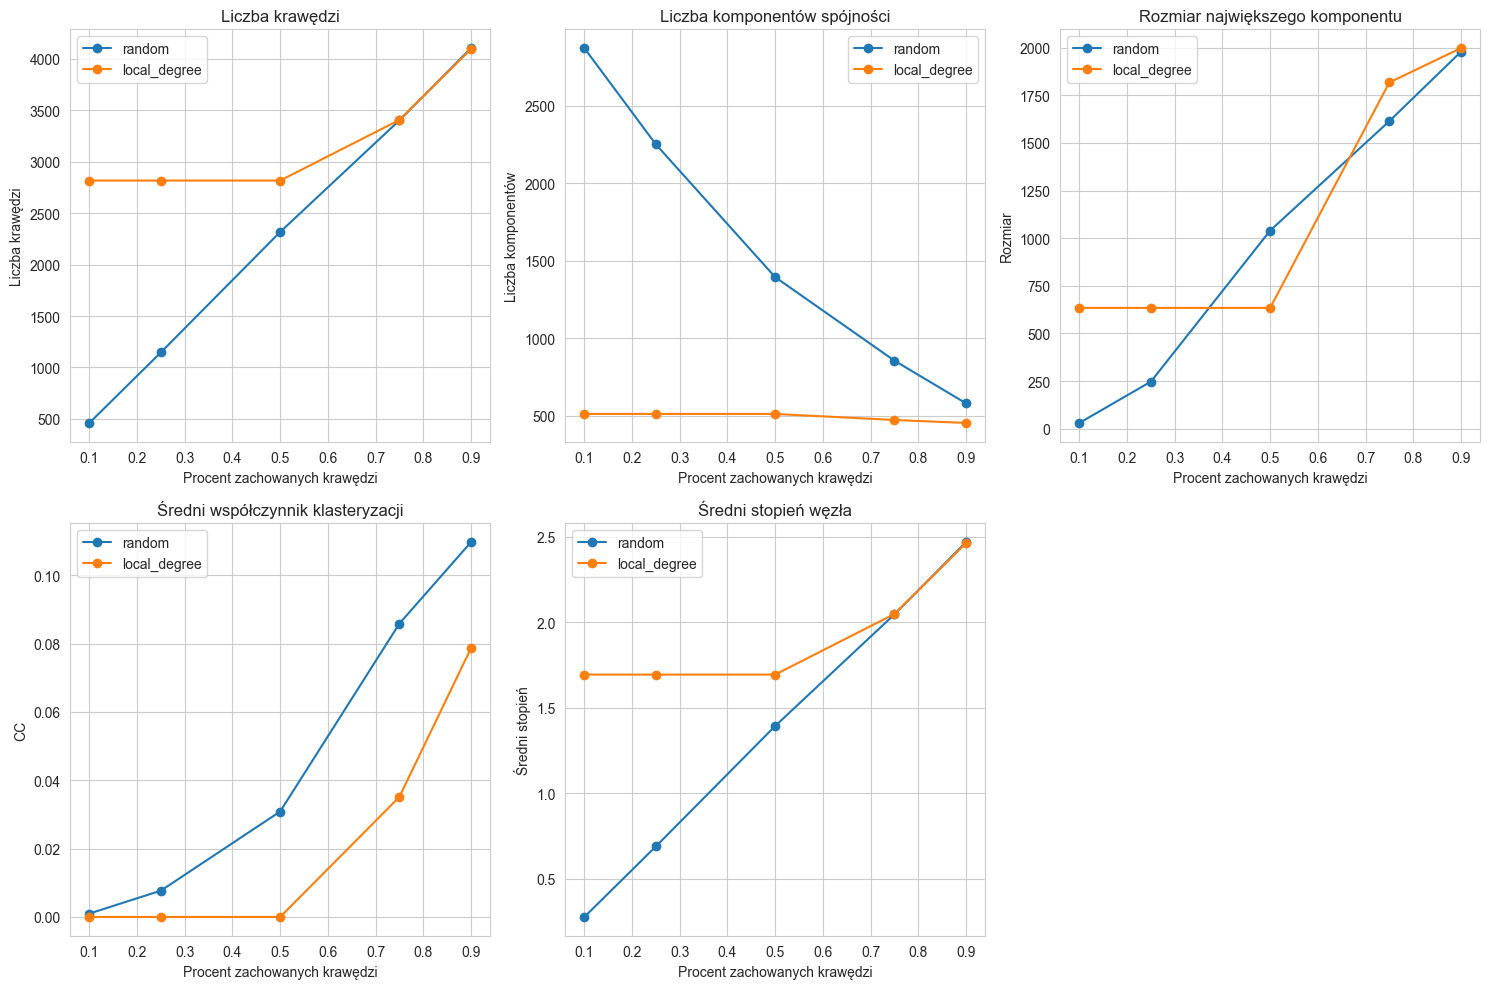

In [ ]:
plt.figure(figsize=(15, 10))

for method, data in results.items():
    ratios, nodes, edges, num_components, largest_component_size, avg_clustering_coefficient, avg_degree = zip(*data)
    
    plt.subplot(2, 3, 1)
    plt.plot(ratios, edges, marker='o', label=method)
    plt.title('Liczba krawędzi')
    plt.xlabel('Procent zachowanych krawędzi')
    plt.ylabel('Liczba krawędzi')
    
    plt.subplot(2, 3, 2)
    plt.plot(ratios, num_components, marker='o', label=method)
    plt.title('Liczba komponentów spójności')
    plt.xlabel('Procent zachowanych krawędzi')
    plt.ylabel('Liczba komponentów')
    
    plt.subplot(2, 3, 3)
    plt.plot(ratios, largest_component_size, marker='o', label=method)
    plt.title('Rozmiar największego komponentu')
    plt.xlabel('Procent zachowanych krawędzi')
    plt.ylabel('Rozmiar')

    plt.subplot(2, 3, 4)
    plt.plot(ratios, avg_clustering_coefficient, marker='o', label=method)
    plt.title('Średni współczynnik klasteryzacji')
    plt.xlabel('Procent zachowanych krawędzi')
    plt.ylabel('CC')

    plt.subplot(2, 3, 5)
    plt.plot(ratios, avg_degree, marker='o', label=method)
    plt.title('Średni stopień węzła')
    plt.xlabel('Procent zachowanych krawędzi')
    plt.ylabel('Średni stopień')

# dodanie legendy do każdego z 5 wykorzystywanych wykresów
for i in range(1, 6):
    plt.subplot(2, 3, i)
    plt.legend()
    
plt.tight_layout()
plt.show()

Wraz ze spadkiem edge_ratio (procentu zachowanych krawędzi) metoda losowej redukcji grafu liniowo zmniejsza liczbę krawędzi w grafie (faktycznie redukuje graf do zadanej liczby krawędzi), natomiast dla LocalDegreeSparsifier widoczny jest inny zupełnie inny trend, który dla mniejszego współczynnika dązy do wypłaszczenia (od pewnego współczynnika nie następuje juz redukcja grafu) - wynika to właśnie z próby zachowania struktury grafu. Analogicznie wygląda wykres średniego stopnia węzła. Próba zachowania struktury widoczna jest równiez przy liczbie komponetów (dla Local widoczna jest mniej więcej stała wartość niezalezna od edge_ratio, natomiast dla Random mamy spadek) oraz rozmiaru największego komponentu, gdzie dla Local następuje próba zachowania proporcjonalnie duzego komponentu.

## Link prediction

celem zadania jest przewidywanie,
czy pomiędzy daną parą węzłów powinna istnieć krawędź.
Problem ten jest formułowany jako zadanie klasyfikacji binarnej,
gdzie:
- klasa pozytywna odpowiada istniejącym krawędziom,
- klasa negatywna odpowiada parom węzłów bez połączenia.

W naszym przypadku celem modelu jest odtworzenie struktury
zredukowanego grafu na podstawie dostępnych danych.

### Negative sampling

proces polegający na losowaniu par węzłów,
które **nie są połączone krawędzią** w grafie.

Jest to kluczowy krok w zadaniu link prediction, ponieważ:
- graf nie zawiera jawnych przykładów negatywnych,
- model klasyfikacyjny wymaga danych obu klas,
- losowanie negatywnych krawędzi umożliwia zbalansowanie zbioru danych.

### Cechy krawędzi (edge features)

w tym ćwiczeniu cechy krawędzi są budowane na podstawie
**embeddingów węzłów uzyskanych metodą Node2Vec**.

Dla każdej krawędzi (u, v):
- pobierane są embeddingi węzłów u i v,
- łączone są w jeden wektor cech.


In [123]:
def sample_negative_edges(
    G: nk.Graph,
    num_samples: int,
    forbidden_edges: set[tuple[int, int]] | None = None,
) -> np.ndarray:
    """
    Funkcja powinna losować "negatywne krawędzie" w grafie, czyli takie, które nie istnieją w grafie G.

    Parametry
    G : nk.Graph
        Graf wejściowy
    num_samples : int
        Liczba negatywnych krawędzi do wylosowania
    forbidden_edges : set[tuple[int,int]] lub None
        Zbiór krawędzi, których NIE można wylosować (np. istniejących w grafie)

    Wskazówki:
    - Pomiń pętle (u==v)
    - Normalizuj pary dla grafu nieskierowanego (u<=v)
    - Pomijaj krawędzie istniejące i zakazane
    - Wylosowane krawędzie mogą być zwracane w formie np. numpy array
    """
    if forbidden_edges is None:
        forbidden_edges = set()

    existing_edges = {(min(u, v), max(u, v)) for u, v in G.iterEdges()}
    forbidden_norm = {(min(u, v), max(u, v)) for u, v in forbidden_edges}
    all_forbidden = existing_edges.union(forbidden_norm)
    neg_edges = []
    n = G.numberOfNodes()

    while len(neg_edges) < num_samples:
        u, v = np.random.randint(0, n, size=2)
        if u == v:
            continue
        edge = (min(u, v), max(u, v))
        if edge in all_forbidden:
            continue
        neg_edges.append(edge)
        all_forbidden.add(edge)

    return np.array(neg_edges)


def get_edge_features(
    edge_list: Iterable[tuple[int, int]],
    emb: np.ndarray,
) -> np.ndarray:
    """
    Funkcja ma tworzyć wektory cech dla krawędzi na podstawie embeddingów węzłów.

    Parametry
    edge_list : Iterable[tuple[int,int]]
        Lista krawędzi, np. [(u1,v1), (u2,v2), ...]
    emb : np.ndarray, shape=(n_nodes, embedding_dim)
        Macierz embeddingów węzłów (np. wynik Node2Vec)

    Output
    np.ndarray, shape=(len(edge_list), embedding_dim)
        Każdy wiersz to wektor cech krawędzi, np. iloczyn Hadamarda
        wektorów węzłów u i v

    Wskazówki:
    - Dla każdej krawędzi (u,v) pobierz emb[u] i emb[v]
    - Połącz je w jedną cechę (np. iloczyn Hadamarda)
    - Zbierz wszystkie krawędzie w jedną tablicę numpy
    """
    features = []
    for u, v in edge_list:
        edge_feature = emb[u] * emb[v]  # Hadamard product
        features.append(edge_feature)
    return np.array(features)


def preprocess_graph(G: nk.Graph) -> nk.Graph:
    """
    Przygotuj graf do Node2Vec

    Wskazówki:
    1. Konwertuj NetworKit -> NetworkX
    2. Usuń izolowane węzły
    3. Przypisz węzłom nowe ID 0..n-1
    4. Konwertuj z powrotem NetworkX -> NetworKit
    """
    G_nx = nk.nxadapter.nk2nx(G)
    G_nx.remove_nodes_from(list(nx.isolates(G_nx)))
    G_preprocessed = nk.nxadapter.nx2nk(G_nx)
    return G_preprocessed

In [113]:
# print edges of G_nk using mapping
print("Edges in G_nk with original node IDs:")
for u, v in G_nk.iterEdges():
    print(f"nk=({u}, {v}), nx=({nk_to_nx[u]}, {nk_to_nx[v]})")

Edges in G_nk with original node IDs:
nk=(0, 1), nx=(0, 628)
nk=(2, 3), nx=(1, 158)
nk=(2, 4), nx=(1, 486)
nk=(2, 5), nx=(1, 1097)
nk=(2, 6), nx=(1, 2919)
nk=(2, 7), nx=(1, 2933)
nk=(3, 5), nx=(158, 1097)
nk=(3, 6), nx=(158, 2919)
nk=(4, 1257), nx=(486, 509)
nk=(4, 5), nx=(486, 1097)
nk=(4, 1363), nx=(486, 1115)
nk=(4, 1043), nx=(486, 1202)
nk=(4, 1320), nx=(486, 1362)
nk=(4, 1364), nx=(486, 1570)
nk=(4, 1365), nx=(486, 2356)
nk=(4, 1258), nx=(486, 2891)
nk=(4, 857), nx=(486, 3228)
nk=(5, 32), nx=(1097, 12)
nk=(5, 486), nx=(1097, 138)
nk=(5, 423), nx=(1097, 150)
nk=(5, 721), nx=(1097, 221)
nk=(5, 487), nx=(1097, 468)
nk=(5, 1511), nx=(1097, 559)
nk=(5, 167), nx=(1097, 1429)
nk=(5, 2362), nx=(1097, 1467)
nk=(5, 129), nx=(1097, 1625)
nk=(5, 425), nx=(1097, 1875)
nk=(5, 280), nx=(1097, 1879)
nk=(5, 48), nx=(1097, 1894)
nk=(5, 2227), nx=(1097, 2427)
nk=(5, 2363), nx=(1097, 2648)
nk=(5, 6), nx=(1097, 2919)
nk=(5, 7), nx=(1097, 2933)
nk=(6, 2633), nx=(2919, 1358)
nk=(6, 1390), nx=(2919, 1575

In [132]:
# budowanie grafu o konkretej kolejnosci wezlow (zeby zachowac koeljnsoc w obu grafach)

nodes_s = sorted(G_nx.nodes())
mapping_s = {node: i for i, node in enumerate(nodes_s)}
G_nk = nk.Graph(len(nodes_s))

for u, v in G_nx.edges():
    G_nk.addEdge(mapping_s[u], mapping_s[v])

In [134]:
reduced_data_path = Path('0_9_citeseer.adjlist')
reduced_G_nx = nx.read_adjlist(reduced_data_path, nodetype=int)

nodes_s = sorted(reduced_G_nx.nodes())
mapping_s = {node: i for i, node in enumerate(nodes_s)}
reduced_G = nk.Graph(len(nodes_s))

for u, v in reduced_G_nx.edges():
    reduced_G.addEdge(mapping_s[u], mapping_s[v])

print(f'Zredukowany graf: {reduced_G.numberOfNodes()} nodes, {reduced_G.numberOfEdges()} edges')

Zredukowany graf: 3327 nodes, 4094 edges


In [135]:
preprocessed_G = preprocess_graph(G_nk)
preprocessed_reduced_G  = preprocess_graph(reduced_G)

orig_edges = list(preprocessed_G.iterEdges())
reduced_edges = list(preprocessed_reduced_G.iterEdges())

removed_edges = list(set(orig_edges) - set(reduced_edges))

print("Original edges:", len(orig_edges))
print("Reduced edges:", len(reduced_edges))
print("Removed edges (to predict):", len(removed_edges))

Original edges: 4552
Reduced edges: 4094
Removed edges (to predict): 458


### Node2Vec
model uczenia reprezentacji węzłów w grafach, która odwzorowuje węzły na wektory w przestrzeni ciągłej, zachowując strukturę sieci. Kluczowym elementem node2vec jest *random walk*. Formalnie, dla danego węzła źródłowego $u$ symulujemy random walk o stałej długości $l$. Niech $c_i$ oznacza i‑ty węzeł w ścieżce, zaczynając od $c_0 = u$. Węzły $c_i$ są generowane zgodnie z rozkładem:

$$
P(c_i = x \mid c_{i-1} = v) = 
\begin{cases}
\frac{\pi_{v x}}{Z}, & \text{if} (v,x) \in E, \\
0, & \text{otherwise},
\end{cases}
$$

gdzie \($\pi_{v x}$\) to nienormalizowane prawdopodobieństwo przejścia między węzłami $v$ i $x$, a \($Z$\) jest stałą normalizującą.

Networkit documentation: https://networkit.github.io/dev-docs/python_api/embedding.html


In [136]:
node2vec = Node2Vec(
    G=preprocessed_reduced_G,
    P=1.0,
    Q=1.0,
    L=80,
    N=20,
    D=128,
)
node2vec.run()
emb_matrix = np.array(node2vec.getFeatures())
print("Embeddings shape:", emb_matrix.shape)

Embeddings shape: (3279, 128)


### Budowa zbioru treningowego

W tym zdaniu zbiór treningowy jest budowany poprzez łączenie
próbek pozytywnych i negatywnych.

W kodzie:
- `sample_negative_edges` - wykorzystujemy do losowania par węzłów,
    pomiędzy którymi nie istnieje krawędź w grafie.
- `edge_features`
- `np.vstack` łączy macierze cech:
  - wiersze odpowiadają poszczególnym krawędziom,
  - najpierw krawędzie istniejące, potem negatywne,
- `np.hstack` łączy wektory etykiet:
  - `1` dla krawędzi istniejących,
  - `0` dla krawędzi negatywnych.

Ten sam proces jest wykorzystywny dla sieci powstałej po redukcji służącej jako zbiór treningowej oraz elementom sieci usuniętym w trakcie redukcji służącej jako zbiór testowy.

In [137]:
forbidden = set(orig_edges)
neg_edges = sample_negative_edges(preprocessed_reduced_G, len(reduced_edges), forbidden_edges=forbidden)

X_train = np.vstack([get_edge_features(reduced_edges, emb_matrix),
                     get_edge_features(neg_edges, emb_matrix)])
y_train = np.hstack([np.ones(len(reduced_edges)), np.zeros(len(neg_edges))])

neg_test = sample_negative_edges(preprocessed_reduced_G, len(removed_edges), forbidden_edges=forbidden)
X_test = np.vstack([get_edge_features(removed_edges, emb_matrix),
                    get_edge_features(neg_test, emb_matrix)])
y_test = np.hstack([np.ones(len(removed_edges)), np.zeros(len(neg_test))])

In [138]:
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Klasy treningowe: pos={int(y_train.sum())}, neg={int((1-y_train).sum())}")
print(f"Klasy testowe: pos={int(y_test.sum())}, neg={int((1-y_test).sum())}")

X_train: (8188, 128), X_test: (916, 128)
Klasy treningowe: pos=4094, neg=4094
Klasy testowe: pos=458, neg=458


In [139]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results_clf = {}

# Logistic Regression
lr_clf = LogisticRegression(random_state=SEED, max_iter=1000)
lr_clf.fit(X_train_scaled, y_train)
y_pred_lr = lr_clf.predict(X_test_scaled)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
results_clf['Logistic Regression'] = f1_lr

# K-Nearest Neighbors
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)
f1_knn = f1_score(y_test, y_pred_knn, average='macro')
results_clf['K-Nearest Neighbors'] = f1_knn

In [ ]:
print("Wyniki klasyfikacji:")
for clf_name, f1 in results_clf.items():
    print(f"{clf_name}: F1-score (macro) = {f1:.4f}")


Wyniki klasyfikacji:
Logistic Regression: F1-score (macro) = 0.7893
K-Nearest Neighbors: F1-score (macro) = 0.7997


In [143]:
configs = [
    {'P': 1.0, 'Q': 1.0, 'L': 80, 'N': 20, 'D': 128, 'label': 'P=1, Q=1 (DeepWalk), L=80, N=20, D=128'},
    {'P': 0.5, 'Q': 2.0, 'L': 80, 'N': 20, 'D': 128, 'label': 'P=0.5, Q=2 (BFS-like), L=80, N=20, D=128'},
    {'P': 2.0, 'Q': 0.5, 'L': 80, 'N': 20, 'D': 128, 'label': 'P=2, Q=0.5 (DFS-like), L=80, N=20, D=128'},
    {'P': 1.0, 'Q': 1.0, 'L': 50, 'N': 10, 'D': 64, 'label': 'P=1, Q=1 (DeepWalk), L=50, N=10, D=64'},
    {'P': 0.5, 'Q': 2.0, 'L': 50, 'N': 10, 'D': 64, 'label': 'P=0.5, Q=2 (BFS-like), L=50, N=10, D=64'},
    {'P': 2.0, 'Q': 0.5, 'L': 50, 'N': 10, 'D': 64, 'label': 'P=2, Q=0.5 (DFS-like), L=50, N=10, D=64'},
]

for cfg in configs:
    n2v = Node2Vec(
        G=preprocessed_reduced_G,
        P=cfg['P'], Q=cfg['Q'],
        L=cfg['L'], N=cfg['N'], D=cfg['D'],
    )
    n2v.run()
    emb = np.array(n2v.getFeatures())

    neg_tr = sample_negative_edges(preprocessed_reduced_G, len(reduced_edges), forbidden)
    neg_te = sample_negative_edges(preprocessed_reduced_G, len(removed_edges), forbidden)

    Xtr = np.vstack([get_edge_features(reduced_edges, emb), get_edge_features(neg_tr, emb)])
    Xte = np.vstack([get_edge_features(removed_edges, emb), get_edge_features(neg_te, emb)])

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    lr_cfg = LogisticRegression(max_iter=1000, random_state=SEED)
    lr_cfg.fit(Xtr_s, y_train)
    f1 = f1_score(y_test, lr_cfg.predict(Xte_s), average='macro')
    print(f"{cfg['label']:30s}  F1={f1:.4f}")

P=1, Q=1 (DeepWalk), L=80, N=20, D=128  F1=0.8198
P=0.5, Q=2 (BFS-like), L=80, N=20, D=128  F1=0.7845
P=2, Q=0.5 (DFS-like), L=80, N=20, D=128  F1=0.8063
P=1, Q=1 (DeepWalk), L=50, N=10, D=64  F1=0.7031
P=0.5, Q=2 (BFS-like), L=50, N=10, D=64  F1=0.6884
P=2, Q=0.5 (DFS-like), L=50, N=10, D=64  F1=0.7256


Do zadania uczenia i klasyfikacji modelu, trzeba było zmienić dotychczasowe podejście budowy grafu przy uzyciu biblioteki NetworKit. Wynika to z faktu, ze to podejście uzywane na początku notebooku:

```
G_nx = nx.read_adjlist(data_path, nodetype=int)
G_nk = nk.nxadapter.nx2nk(G_nx)
```

budowała graf indeksując wierzchołki na nowo w kolejności ich pojawiania się w liście sąsiedztwa. Niespójność między plikami `citeseer.adjlist` oraz `0_9_citeseer.adjlist` wynikająca z usunięcia części krawędzi z tego drugiego pliku powodowała rozbiezność indeksów w grafach dla niektórych, tych samych wierzchołków (z oryginalnych danych).

Wobec tego postanowiono budować graf poprzez iteracyjne dodawanie krawędzi dla posortowanych wierzchołków, dzięki czemu zachowane zostało odpowiednie mapowanie indeksów w obu grafach.

#### Klasyfikacja:

Wykonano zadanie klasyfikacji dla dwóch modeli `LogisticRegression` i `KNN` uzyskując podobne wyniki miary F1 macro, z niewielką przewagą klasyfikatora `KNN`

#### Wpływ hiperparametrów:

Przetestowano wpływ parametru powrotu (P) oraz parametru odejścia dalej (Q). Wartości F1_macro były zblizone, natomiast ustawienie tego parametru na P=1, Q=1 (spacer losowy) oraz P=2, Q=0.5 (bardziej zachowanie jak DFS) dawało lepsze rezultaty - z przewagą spaceru losowego. 

Przetestowano równiez wpływ parametrów dotyczących długości spaceru (L), liczby spacerów na węzeł (N) i wymiaru embeddingu (D) zmniejszając ich wartości względem testu pierwszego. Wyniki otrzymane były zauwazalnie gorsze niz dla testu 1. W tym przypadku lepiej poradził sobie przypadek z eksploracją w stylu DFS
